In [2]:
import numpy as np
import sys
sys.path.append('..')  # Add parent directory to Python path
from notebooks.video_io import load_frames
from notebooks.utils import filter_and_label_spatiotemporal_propagation
from tqdm import tqdm
from scipy import ndimage

import matplotlib.pyplot as plt
plt.rcParams['image.origin'] = 'lower'  # Set default origin to lower
plt.rcParams['image.cmap'] = 'gray'  # Set default origin to lower

In [3]:
import numpy as np
from scipy import ndimage as ndi
from scipy.spatial.distance import cdist
from tqdm import tqdm
import matplotlib.pyplot as plt

def create_temporal_window(binary_video, current_frame, time_window):
    """Extract temporal window around current frame."""
    time_frames = binary_video.shape[0]
    start_t = max(0, current_frame - time_window // 2)
    end_t = min(time_frames, current_frame + time_window // 2 + 1)
    return binary_video[start_t:end_t], start_t

def filter_by_size(labels, min_size):
    """Filter components based on minimum size."""
    component_sizes = np.bincount(labels.ravel())[1:]
    size_mask = np.zeros_like(labels)
    size_mask[labels > 0] = component_sizes[labels[labels > 0] - 1] >= min_size
    return size_mask

def check_spatial_propagation(size_mask, current_frame_index, space_window):
    """Check if features show spatial propagation between frames."""
    height, width = size_mask.shape[1:]
    prop_mask = np.zeros_like(size_mask)
    
    for y in range(height):
        for x in range(width):
            if size_mask[current_frame_index, y, x]:
                has_prev = current_frame_index > 0
                has_next = current_frame_index < size_mask.shape[0] - 1
                
                # Check previous frame neighborhood
                if has_prev:
                    y_slice = slice(max(0, y - space_window // 2), 
                                 min(height, y + space_window // 2 + 1))
                    x_slice = slice(max(0, x - space_window // 2),
                                 min(width, x + space_window // 2 + 1))
                    prev_neighborhood = size_mask[current_frame_index - 1, y_slice, x_slice]
                    if np.any(prev_neighborhood):
                        prop_mask[current_frame_index, y, x] = 1
                        continue
                
                # Check next frame neighborhood
                if has_next:
                    y_slice = slice(max(0, y - space_window // 2),
                                 min(height, y + space_window // 2 + 1))
                    x_slice = slice(max(0, x - space_window // 2),
                                 min(width, x + space_window // 2 + 1))
                    next_neighborhood = size_mask[current_frame_index + 1, y_slice, x_slice]
                    if np.any(next_neighborhood):
                        prop_mask[current_frame_index, y, x] = 1
    
    return prop_mask

def match_and_label_features(current_labels, current_centroids, feature_history, t, space_window):
    """Match current features with previous ones and assign consistent labels."""
    new_labeling = np.zeros_like(current_labels)
    next_label = max(feature_history.keys()) + 1 if feature_history else 1
    
    # Get previous frame information
    prev_centroids = [feature_history[label]["centroid"] 
                     for label in feature_history 
                     if feature_history[label]["last_frame"] == t - 1]
    prev_labels = [label for label in feature_history 
                  if feature_history[label]["last_frame"] == t - 1]
    
    if t > 0 and prev_centroids:
        # Calculate distances between current and previous centroids
        distances = cdist(current_centroids, prev_centroids)
        
        # Match features based on minimum distance
        for i, centroid in enumerate(current_centroids):
            if len(prev_centroids) > 0:
                min_dist_index = np.argmin(distances[i])
                if distances[i][min_dist_index] < space_window:
                    # Match found
                    matched_label = prev_labels[min_dist_index]
                    mask = current_labels == i + 1
                    new_labeling[mask] = matched_label
                    feature_history[matched_label] = {
                        "centroid": centroid,
                        "last_frame": t
                    }
                    distances[:, min_dist_index] = np.inf
                else:
                    # No close match
                    mask = current_labels == i + 1
                    new_labeling[mask] = next_label
                    feature_history[next_label] = {
                        "centroid": centroid,
                        "last_frame": t
                    }
                    next_label += 1
    else:
        # First frame or no previous features
        for i, centroid in enumerate(current_centroids):
            mask = current_labels == i + 1
            new_labeling[mask] = next_label
            feature_history[next_label] = {
                "centroid": centroid,
                "last_frame": t
            }
            next_label += 1
    
    return new_labeling, feature_history

def process_video_frame(binary_video, t, min_size, time_window, space_window, feature_history):
    """Process a single frame of the video."""
    # Get temporal window
    temp_window, start_t = create_temporal_window(binary_video, t, time_window)
    
    # Label connected components
    structure = np.ones((min(time_window, 3), 3, 3))
    labels, _ = ndi.label(temp_window, structure=structure)
    
    # Apply size filter
    size_mask = filter_by_size(labels, min_size)
    
    # Check propagation
    prop_mask = check_spatial_propagation(size_mask, t - start_t, space_window)
    
    # Get current frame features
    current_frame = size_mask[t - start_t] & prop_mask[t - start_t]
    current_labels, _ = ndi.label(current_frame)
    
    # Calculate centroids
    current_centroids = ndi.center_of_mass(current_frame, current_labels, 
                                         range(1, current_labels.max() + 1))
    
    # Match and label features
    if len(current_centroids) > 0:
        new_labeling, feature_history = match_and_label_features(
            current_labels, current_centroids, feature_history, t, space_window)
    else:
        new_labeling = np.zeros_like(current_labels)
    
    return new_labeling, feature_history

def filter_and_label_spatiotemporal_propagation(binary_video, min_size=1, 
                                              time_window=3, space_window=3):
    """Main function to process the entire video."""
    filtered_video = np.zeros_like(binary_video, dtype=int)
    feature_history = {}
    
    for t in tqdm(range(binary_video.shape[0])):
        new_labeling, feature_history = process_video_frame(
            binary_video, t, min_size, time_window, space_window, feature_history)
        filtered_video[t] = new_labeling
        
        # Clean up old features
        for label in list(feature_history.keys()):
            if t - feature_history[label]["last_frame"] >= time_window:
                del feature_history[label]
    
    return filtered_video

# Example usage and visualization
def visualize_tracking(binary_video, labeled_video, frame_indices):
    """Visualize original and labeled frames side by side."""
    n_frames = len(frame_indices)
    fig, axes = plt.subplots(n_frames, 2, figsize=(10, 4*n_frames))
    
    for i, frame_idx in enumerate(frame_indices):
        # Original frame
        axes[i, 0].imshow(binary_video[frame_idx], cmap='binary')
        axes[i, 0].set_title(f'Original Frame {frame_idx}')
        axes[i, 0].axis('off')
        
        # Labeled frame
        labeled_frame = labeled_video[frame_idx]
        axes[i, 1].imshow(labeled_frame, cmap='nipy_spectral')
        axes[i, 1].set_title(f'Labeled Frame {frame_idx}')
        axes[i, 1].axis('off')
    
    plt.tight_layout()
    return fig

0.4064gb allocated


100%|██████████| 508/508 [00:27<00:00, 18.66it/s]


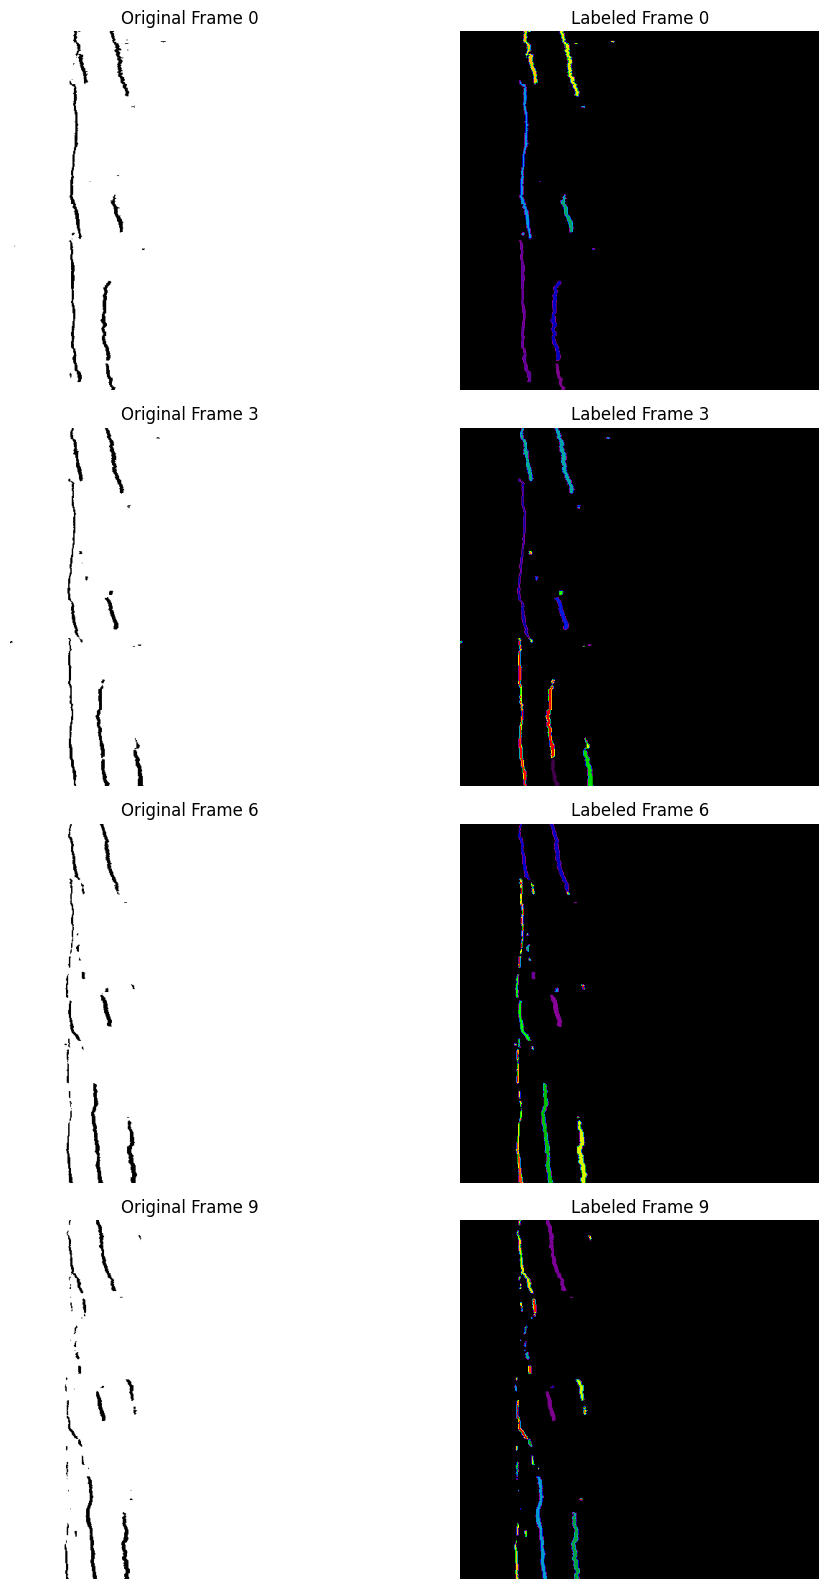

In [5]:
ts = load_frames('results/20241120/test/20211026T160100Z_breakers.avi')
ts = np.flip(ts, 1)
ts = np.swapaxes(ts, 1, 2)[:, :500, :]
ts.shape

labeled_video = filter_and_label_spatiotemporal_propagation(
    ts,
    min_size=5,
    time_window=3,
    space_window=5
)

# Visualize results
frame_indices = [0, 3, 6, 9]  # Show a few frames
fig = visualize_tracking(ts, labeled_video, frame_indices)
